In [4]:
!pip install -q Sastrawi tensorflow scikit-learn pandas numpy matplotlib seaborn

In [5]:
import os, re, json, random, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## 1. Data Loading & Exploration

In [6]:
df_raw = pd.read_csv('Sentimen_Cleaned.csv')
df = df_raw[['Kritik dan saran', 'Sentimen']].copy()
df.columns = ['text', 'label']
df = df.dropna()
df = df[df['text'].str.strip().str.len() > 3].reset_index(drop=True)

print("Shape:", df.shape)
print()
print("Distribusi label:")
print(df['label'].value_counts())
print()
print(df['label'].value_counts(normalize=True).round(3))

Shape: (8007, 2)

Distribusi label:
label
positif    4122
netral     2689
negatif    1196
Name: count, dtype: int64

label
positif    0.515
netral     0.336
negatif    0.149
Name: proportion, dtype: float64


Panjang teks — mean: 15.0, median: 9.0, max: 436


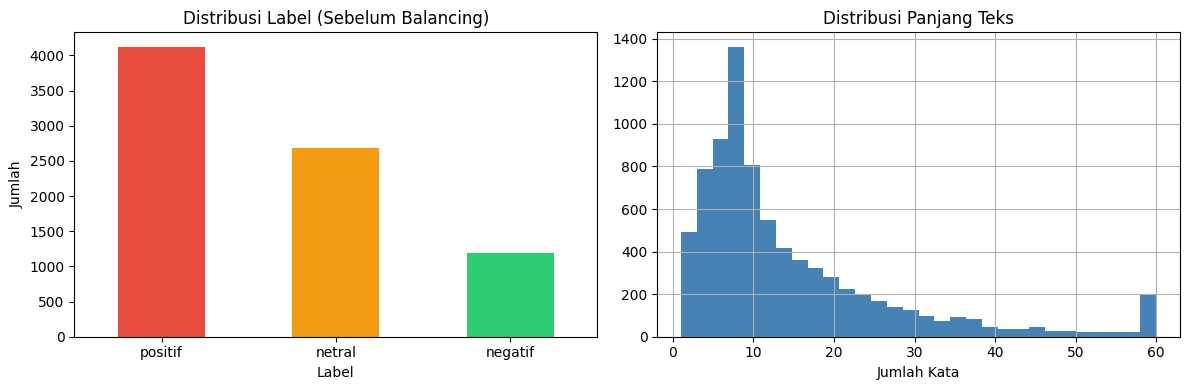

In [7]:
df['word_count'] = df['text'].str.split().str.len()
print(f"Panjang teks — mean: {df['word_count'].mean():.1f}, median: {df['word_count'].median()}, max: {df['word_count'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Distribusi Label (Sebelum Balancing)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(rotation=0)

df['word_count'].clip(upper=60).hist(bins=30, ax=axes[1], color='steelblue')
axes[1].set_title('Distribusi Panjang Teks')
axes[1].set_xlabel('Jumlah Kata')
plt.tight_layout()
plt.show()

## 2. Preprocessing Pipeline

In [8]:
_stem_factory = StemmerFactory()
_stemmer = _stem_factory.create_stemmer()

_sw_factory = StopWordRemoverFactory()
_all_stopwords = set(_sw_factory.get_stop_words())

_sentiment_keep = {
    'tidak','tak','bukan','tanpa','jangan','belum','namun','tapi','tetapi',
    'sangat','sekali','banget','amat','terlalu','lebih','kurang','cukup',
    'agak','lumayan','sedikit','banyak',
    'baik','bagus','buruk','jelek','enak','susah','mudah','sulit','gampang',
    'senang','puas','kecewa','nyaman','aman','bahaya','parah','berat',
    'seru','membosankan','menarik','membingungkan','menyenangkan','mengecewakan',
    'cepat','lambat','lancar','error','gagal','berhasil','ngelag','lag','loading',
    'perlu','harus','bisa','mampu','ingin','mau','butuh',
    'semoga','harap','tolong','mohon','sarankan','harapkan',
    'penting','kritis','darurat','mendesak',
    'kacau','berantakan','tidak karuan','amburadul',
    'bosen','bosan','capek','lelah','males','malas',
    'keren','mantap','luar biasa','hebat','oke','ok',
    'sayang','sayangnya','disayangkan',
    'ribet','rumit','susah banget','gak jelas','ngga jelas',
    'nggak','engga','enggak','gak','ga','ngga',
    'mending','断然','memprihatinkan',
}

_stopwords_filtered = _all_stopwords - _sentiment_keep

_slang_dict = {
    "ga":"tidak","gak":"tidak","gk":"tidak","ngga":"tidak",
    "nggak":"tidak","enggak":"tidak","engga":"tidak",
    "kagak":"tidak","kaga":"tidak","gakbisa":"tidak bisa",
    "bgt":"banget","bngt":"banget","bgtt":"banget",
    "yg":"yang","dgn":"dengan","utk":"untuk","krn":"karena",
    "sdh":"sudah","blm":"belum","jg":"juga","lg":"lagi",
    "tp":"tapi","gpp":"tidak apa","mksh":"terima kasih","tks":"terima kasih",
    "makasih":"terima kasih","makasi":"terima kasih",
    "moga":"semoga","smg":"semoga",
    "depan":"ke depan","kedepan":"ke depan",
    "lmyn":"lumayan","lumya":"lumayan",
    "ngeleg":"ngelag","lag":"ngelag","loading":"lambat",
    "eror":"error","err":"error",
    "oke":"ok","okee":"ok","okelah":"ok",
    "klo":"kalau","klu":"kalau","kl":"kalau","klw":"kalau",
    "udh":"sudah","udah":"sudah","dah":"sudah",
    "nih":"ini","tuh":"itu",
    "bener":"benar","bner":"benar",
    "gmn":"bagaimana","gimana":"bagaimana",
    "knp":"kenapa","kpn":"kapan",
    "mhs":"mahasiswa","maba":"mahasiswa baru",
    "pnitia":"panitia","pnit":"panitia",
    "acc":"disetujui","fix":"sudah pasti",
    "auto":"otomatis","reload":"muat ulang",
    "down":"mati","offline":"tidak ada","online":"daring",
    "update":"perbarui","upgrade":"tingkatkan",
    "user":"pengguna","server":"server","website":"website","web":"website",
    "smpb":"spmb","ppkmb":"pkkmb","pkmb":"pkkmb",
    "unpam":"universitas","kampus":"kampus",
    "mau":"ingin","pengen":"ingin","pengin":"ingin",
    "cape":"capek","capeee":"capek",
    "boring":"membosankan","bored":"bosan","bore":"bosan",
    "bad":"buruk","good":"baik","ok":"baik",
    "thanks":"terima kasih","thx":"terima kasih","ty":"terima kasih",
    "mantul":"mantap","mantap":"mantap","keren":"keren",
    "parah":"parah","ancur":"hancur","rusak":"rusak",
}

def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [_slang_dict.get(w, w) for w in tokens]
    tokens = [w for w in tokens if w not in _stopwords_filtered and len(w) > 1]
    text = ' '.join(tokens)
    text = _stemmer.stem(text)
    return text.strip()

print("Preprocessing sample:")
samples = [
    "Untuk servernya full dan error jadi agak susah saat mengerjakan",
    "Sudah baik untuk tahun ini namun akan lebih baik jika di laksanakan secara langsung",
    "Semoga lebih baik",
    "membosankan",
    "website ngelag parah banget gak bisa akses sama sekali",
    "Tolong perbaiki sistem PKKMB yang sangat kacau ini",
]
for s in samples:
    print(f"  IN : {s}")
    print(f"  OUT: {preprocess(s)}")
    print()

Preprocessing sample:
  IN : Untuk servernya full dan error jadi agak susah saat mengerjakan
  OUT: servernya full error jadi agak susah kerja

  IN : Sudah baik untuk tahun ini namun akan lebih baik jika di laksanakan secara langsung
  OUT: baik tahun namun lebih baik laksana langsung

  IN : Semoga lebih baik
  OUT: moga lebih baik

  IN : membosankan
  OUT: bosan

  IN : website ngelag parah banget gak bisa akses sama sekali
  OUT: website ngelag parah banget tidak bisa akses sama sekali

  IN : Tolong perbaiki sistem PKKMB yang sangat kacau ini
  OUT: tolong baik sistem pkkmb sangat kacau



In [9]:
print("Applying preprocessing to all data...")
df['clean_text'] = df['text'].apply(preprocess)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)

label_map = {'negatif': 0, 'netral': 1, 'positif': 2}
df['label_int'] = df['label'].map(label_map)
df = df.dropna(subset=['label_int'])
df['label_int'] = df['label_int'].astype(int)

print("Done. Shape:", df.shape)
print("Label distribution after preprocessing:")
print(df['label'].value_counts())

Applying preprocessing to all data...
Done. Shape: (8003, 5)
Label distribution after preprocessing:
label
positif    4120
netral     2687
negatif    1196
Name: count, dtype: int64


## 3. Data Augmentation & Balancing

In [10]:
augmented_negative = [
    "servernya full error susah kerja",
    "website ngelag tidak bisa akses",
    "login susah server lambat parah",
    "sistem eror terus tidak bisa masuk",
    "link tidak bisa dibuka ngelag banget",
    "web pkkmb sangat lambat tidak nyaman",
    "tidak bisa akses sama sekali error",
    "server down tidak bisa login",
    "website error terus parah banget",
    "susah akses web pkkmb online",
    "pkkmb membosankan tidak ada manfaat",
    "acara tidak menarik sama sekali",
    "materi tidak jelas membingungkan",
    "sangat mengecewakan tidak edukatif",
    "pkkmb tidak kondusif kacau",
    "tidak seru sama sekali buang waktu",
    "sangat kecewa dengan pelaksanaan pkkmb",
    "panitia tidak profesional acara berantakan",
    "pkkmb berantakan tidak terorganisir",
    "tidak ada manfaat membuang waktu",
    "materi tidak sampai membingungkan",
    "informasi tidak jelas kurang sosialisasi",
    "jadwal tidak tepat waktu molor terus",
    "koordinasi panitia sangat buruk",
    "tidak komunikatif informasi kurang jelas",
    "pkkmb online sangat membosankan",
    "kurang persiapan acara tidak matang",
    "sistem tidak user friendly sulit digunakan",
    "tidak nyaman sama sekali acara kacau",
    "pkkmb online ganggu waktu kerja",
    "terlalu banyak joget tidak edukatif",
    "koneksi internet sering putus saat pkkmb",
    "server tidak kuat banyak yang tidak bisa masuk",
    "aplikasi spmb sulit diakses error terus",
    "susah mengerjakan tugas pkkmb web error",
    "pkkmb tidak sesuai ekspektasi kecewa",
    "pelaksanaan tidak maksimal sangat disayangkan",
    "panitia tidak responsif tidak membantu",
    "informasi mendadak tidak ada pemberitahuan awal",
    "pkkmb terlalu lama tidak efektif",
    "tidak efektif membuang banyak waktu",
    "sangat kecewa acara tidak sesuai harapan",
    "website crash tidak bisa digunakan sama sekali",
    "loading lama tidak bisa submit",
    "sistem pkkmb sangat bermasalah parah",
    "acara tidak terstruktur membingungkan mahasiswa",
    "kurang koordinasi panitia amburadul",
    "pkkmb tidak bermanfaat bagi mahasiswa baru",
    "materi disampaikan tidak menarik membosankan",
    "pemateri tidak jelas susah dipahami",
    "jaringan bermasalah tidak bisa ikut pkkmb",
    "website down saat pkkmb berlangsung parah",
    "tidak ada panduan jelas untuk mahasiswa baru",
    "pkkmb kacau tidak ada kejelasan",
    "sangat disayangkan pelaksanaan sangat buruk",
    "tidak puas dengan pkkmb tahun ini",
    "banyak kendala teknis tidak diantisipasi",
    "sistem login bermasalah parah tidak bisa masuk",
    "waktu tidak efisien acara molor terus",
    "sangat tidak memuaskan harap diperbaiki",
    "link zoom tidak bisa dibuka error",
    "tidak bisa submit tugas website error",
    "pkkmb sangat mengecewakan tidak ada persiapan",
    "panitia tidak sigap dalam menangani masalah",
    "materi tidak relevan tidak berguna",
    "terlalu banyak tugas tidak sebanding manfaat",
    "pkkmb online tidak efektif sama sekali",
    "tidak kondusif banyak gangguan saat acara",
    "server tidak stabil sering down",
    "sulit memahami materi karena koneksi buruk",
    "pkkmb tidak memberikan manfaat nyata",
    "sangat kecewa dengan sistem yang buruk",
    "website tidak responsif susah digunakan",
    "acara tidak sesuai jadwal sangat mengganggu",
    "informasi kurang sosialisasi terlambat",
    "pkkmb tidak menyenangkan membosankan",
    "tidak ada interaksi acara sangat membosankan",
    "sistem daftar ulang pkkmb sangat ribet",
    "tidak jelas prosedurnya membingungkan mahasiswa baru",
    "pkkmb online kurang interaktif tidak menarik",
    "konten pkkmb tidak berkualitas mengecewakan",
    "waktu pelaksanaan tidak sesuai sangat mengganggu",
    "tidak bisa mengakses materi pkkmb error",
    "panitia tidak siap acara berantakan kacau",
    "pkkmb tidak membantu adaptasi mahasiswa baru",
    "sangat kecewa server tidak bisa diakses",
    "tidak puas pelaksanaan pkkmb tahun ini",
    "website pkkmb sangat tidak user friendly",
    "error terus tidak bisa menyelesaikan tugas",
    "pkkmb terlalu formal tidak menarik",
    "tidak ada solusi cepat saat ada masalah teknis",
    "pelaksanaan pkkmb jauh dari kata baik",
    "sangat mengecewakan harap ada perbaikan",
    "sistem absensi error tidak terekam",
    "link zoom mati di tengah acara parah",
    "tidak dapat sertifikat karena sistem error",
    "pkkmb online tidak setara offline kualitasnya",
    "sangat tidak nyaman ikut pkkmb dengan sistem ini",
    "banyak mahasiswa tidak bisa akses sistem",
    "kurang maksimal perlu banyak perbaikan mendasar",
    "pkkmb tahun ini paling buruk yang pernah ada",
    "mengecewakan sekali tidak layak disebut pkkmb",
    "sistem tidak bekerja dengan baik sangat frustasi",
    "tidak ada backup plan saat sistem bermasalah",
    "pkkmb ini membuang waktu tidak ada nilai tambah",
    "sangat tidak puas dengan penyelenggaraan pkkmb ini",
]

augmented_neutral = [
    "pkkmb online cukup baik tapi perlu ditingkatkan",
    "semoga tahun depan lebih baik lagi",
    "ada kekurangan tapi lumayan untuk pertama kali",
    "mohon informasi lebih jelas dan tepat waktu",
    "perlu ditingkatkan lagi untuk pkkmb berikutnya",
    "belum sempurna tapi bisa diterima",
    "cukup informatif meskipun ada beberapa kendala",
    "lumayan baik perlu beberapa perbaikan",
    "tidak buruk tapi masih bisa lebih baik",
    "harap diperbaiki untuk kedepannya",
    "tolong tingkatkan kualitas sistem pkkmb",
    "masih ada kekurangan di sana sini",
    "semoga pkkmb offline bisa dilakukan lagi",
    "masukan untuk panitia agar lebih terorganisir",
    "belum memuaskan tapi oke lah untuk kondisi ini",
    "cukup oke meski tidak sempurna",
    "perlu perbaikan di beberapa aspek",
    "harapannya pkkmb makin baik setiap tahun",
    "mohon jadwal lebih teratur ke depannya",
    "informasi sebaiknya disampaikan lebih awal",
    "acara pkkmb standar tidak buruk tidak terlalu baik",
    "semoga sistem lebih stabil untuk pkkmb selanjutnya",
    "perlu koordinasi lebih baik antara panitia",
    "cukup membantu walaupun ada kendala teknis",
    "tolong perbaiki beberapa hal yang masih kurang",
    "tidak terlalu berkesan tapi tidak mengecewakan",
    "perlu peningkatan di sisi teknis dan konten",
    "semoga ke depan pkkmb bisa lebih interaktif",
    "lumayan untuk kondisi pandemi tapi bisa lebih baik",
    "mohon perhatikan kualitas audio dan video streaming",
    "harap ada sesi tanya jawab lebih banyak",
    "secara keseluruhan cukup namun perlu penyesuaian",
    "tidak jelek tidak bagus perlu ditingkatkan",
    "ada hal baik dan buruk dari pkkmb ini",
    "semoga panitia terus belajar dan berkembang",
    "perlu evaluasi mendalam setelah pkkmb selesai",
    "tolong jadikan pkkmb lebih bermakna ke depan",
    "sudah lumayan tinggal dipoles di beberapa bagian",
    "cukup untuk standar tapi bisa lebih optimal",
    "harap sistem lebih dipersiapkan dengan matang",
]

augmented_positive = [
    "pkkmb sangat menyenangkan dan informatif sekali",
    "panitia sangat ramah dan membantu mahasiswa baru",
    "acara pkkmb luar biasa terima kasih panitia",
    "materi pkkmb sangat berguna dan relevan",
    "sistem pkkmb tahun ini jauh lebih baik",
    "sangat puas dengan pelaksanaan pkkmb",
    "pkkmb memberikan banyak manfaat bagi mahasiswa baru",
    "senang bisa ikut pkkmb yang sangat bermakna",
    "acara berjalan lancar dan menyenangkan",
    "informasi disampaikan dengan jelas dan menarik",
    "pkkmb tahun ini keren banget mantap panitia",
    "sangat terkesan dengan persiapan panitia yang matang",
    "website pkkmb mudah diakses dan user friendly",
    "sistem berjalan lancar tidak ada kendala",
    "pkkmb sangat membantu adaptasi di kampus baru",
    "materi sangat relevan dan mudah dipahami",
    "panitia sigap dan responsif dalam membantu",
    "pkkmb online ternyata seru dan interaktif",
    "sangat senang bisa mengikuti pkkmb tahun ini",
    "semua berjalan dengan baik dan terorganisir",
    "pkkmb ini benar benar memberikan pengalaman berharga",
    "terima kasih panitia sudah bekerja keras",
    "sangat puas sistem lancar acara bagus",
    "pkkmb mempersiapkan mahasiswa baru dengan baik",
    "kesan pkkmb tahun ini sangat positif dan menyenangkan",
    "informasi lengkap dan mudah dipahami bagus sekali",
    "acara sangat tertata rapi dan profesional",
    "pkkmb online sukses tidak mengecewakan sama sekali",
    "sistem berjalan baik lancar tanpa masalah",
    "sangat berterima kasih atas pkkmb yang luar biasa ini",
    "pemateri sangat kompeten materi mudah dicerna",
    "pkkmb tahun ini jauh melampaui ekspektasi",
    "senang sekali bisa bergabung di kampus ini lewat pkkmb",
    "panitia profesional acara sangat terorganisir",
    "pkkmb memberikan semangat untuk kuliah",
]

df_aug_neg = pd.DataFrame({'clean_text': [preprocess(t) for t in augmented_negative], 'label_int': 0, 'label': 'negatif'})
df_aug_neu = pd.DataFrame({'clean_text': [preprocess(t) for t in augmented_neutral], 'label_int': 1, 'label': 'netral'})
df_aug_pos = pd.DataFrame({'clean_text': [preprocess(t) for t in augmented_positive], 'label_int': 2, 'label': 'positif'})

df_combined = pd.concat([df[['clean_text','label_int','label']], df_aug_neg, df_aug_neu, df_aug_pos], ignore_index=True)
df_combined = df_combined[df_combined['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)

print("Distribusi setelah augmentasi:")
print(df_combined['label'].value_counts())
print(df_combined['label'].value_counts(normalize=True).round(3))

Distribusi setelah augmentasi:
label
positif    4155
netral     2727
negatif    1302
Name: count, dtype: int64
label
positif    0.508
netral     0.333
negatif    0.159
Name: proportion, dtype: float64


Distribusi setelah balancing:
label
negatif    2800
netral     2800
positif    2800
Name: count, dtype: int64
label
negatif    0.333
netral     0.333
positif    0.333
Name: proportion, dtype: float64


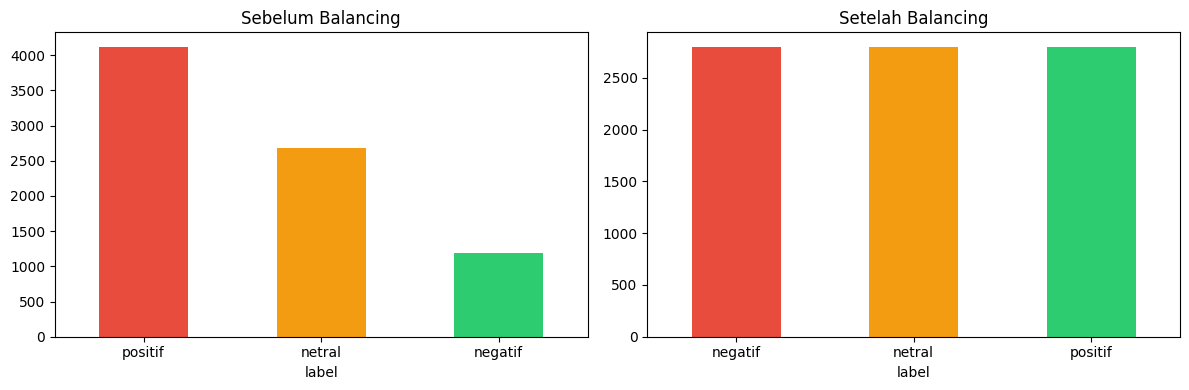

In [11]:
from sklearn.utils import resample

df_neg = df_combined[df_combined['label_int'] == 0]
df_neu = df_combined[df_combined['label_int'] == 1]
df_pos = df_combined[df_combined['label_int'] == 2]

TARGET = 2800

df_neg_up = resample(df_neg, replace=True, n_samples=TARGET, random_state=42)
df_neu_bal = resample(df_neu, replace=False if len(df_neu) >= TARGET else True, n_samples=TARGET, random_state=42)
df_pos_down = resample(df_pos, replace=False, n_samples=TARGET, random_state=42)

df_balanced = pd.concat([df_neg_up, df_neu_bal, df_pos_down], ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribusi setelah balancing:")
print(df_balanced['label'].value_counts())
print(df_balanced['label'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Sebelum Balancing')
axes[0].tick_params(rotation=0)

df_balanced['label'].value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#2ecc71'])
axes[1].set_title('Setelah Balancing')
axes[1].tick_params(rotation=0)
plt.tight_layout()
plt.show()

## 4. Train / Validation Split

In [12]:
X = df_balanced['clean_text'].values
y = df_balanced['label_int'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train = y_train.astype(np.int32)
y_val   = y_val.astype(np.int32)

print(f"Train: {len(X_train)} | Val: {len(X_val)}")
print("Train dist:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val dist  :", dict(zip(*np.unique(y_val, return_counts=True))))

Train: 6720 | Val: 1680
Train dist: {np.int32(0): np.int64(2240), np.int32(1): np.int64(2240), np.int32(2): np.int64(2240)}
Val dist  : {np.int32(0): np.int64(560), np.int32(1): np.int64(560), np.int32(2): np.int64(560)}


## 5. Text Vectorization

In [13]:
MAX_VOCAB = 12000
MAX_LEN   = 50

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_VOCAB,
    output_mode='int',
    output_sequence_length=MAX_LEN,
    ngrams=2,
    name='text_vectorizer'
)

vectorizer.adapt(X_train)

vocab = vectorizer.get_vocabulary()
print(f"Vocabulary size: {len(vocab)}")
print(f"Sample vocab: {vocab[2:10]}")

vectorizer_config = {
    "config": vectorizer.get_config(),
    "vocabulary": vocab
}
with open("vectorizer_config.json", "w", encoding="utf-8") as f:
    json.dump(vectorizer_config, f, ensure_ascii=False)
print("vectorizer_config.json disimpan")

Vocabulary size: 12000
Sample vocab: [np.str_('pkkmb'), np.str_('tidak'), np.str_('lebih'), np.str_('giat'), np.str_('sangat'), np.str_('mahasiswa'), np.str_('daring'), np.str_('pkkmb tidak')]
vectorizer_config.json disimpan


In [14]:
X_train_vec = vectorizer(X_train)
X_val_vec   = vectorizer(X_val)

print("X_train_vec shape:", X_train_vec.shape)
print("X_val_vec shape  :", X_val_vec.shape)

X_train_vec shape: (6720, 50)
X_val_vec shape  : (1680, 50)


## 6. Custom Components (Layer, Loss, Callback)

In [15]:
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], 1),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        score = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)
        context = attention_weights * inputs
        context = tf.reduce_sum(context, axis=1)
        return context

    def get_config(self):
        return super(AttentionLayer, self).get_config()

print("AttentionLayer (Custom Layer) siap")

AttentionLayer (Custom Layer) siap


In [16]:
class WeightedSparseCCE(tf.keras.losses.Loss):
    def __init__(self, class_weights_dict, **kwargs):
        super(WeightedSparseCCE, self).__init__(**kwargs)
        self.class_weights_dict = class_weights_dict
        self._weights_tensor = tf.constant(
            [class_weights_dict[i] for i in sorted(class_weights_dict)],
            dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        cce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        y_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        sample_weights = tf.gather(self._weights_tensor, y_int)
        return tf.reduce_mean(sample_weights * cce)

    def get_config(self):
        config = super(WeightedSparseCCE, self).get_config()
        config.update({
            'class_weights_dict': {int(k): float(v) for k, v in self.class_weights_dict.items()}
        })
        return config

cw_array = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train)
class_weights = {i: float(w) for i, w in enumerate(cw_array)}
print("Class weights:", class_weights)

weighted_loss = WeightedSparseCCE(class_weights)
print("WeightedSparseCCE (Custom Loss) siap")

Class weights: {0: 1.0, 1: 1.0, 2: 1.0}
WeightedSparseCCE (Custom Loss) siap


In [17]:
class DetailedLoggingCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        print("=" * 60)
        print("Training Dimulai")
        print("=" * 60)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        tr_acc  = logs.get('accuracy', 0)
        val_acc = logs.get('val_accuracy', 0)
        tr_loss = logs.get('loss', 0)
        vl_loss = logs.get('val_loss', 0)
        gap     = tr_acc - val_acc
        status  = "OVERFIT" if gap > 0.10 else "OK"
        print(
            f"Epoch {epoch+1:02d} | "
            f"loss: {tr_loss:.4f} acc: {tr_acc:.4f} | "
            f"val_loss: {vl_loss:.4f} val_acc: {val_acc:.4f} | "
            f"gap: {gap:.4f} [{status}]"
        )

    def on_train_end(self, logs=None):
        print("=" * 60)
        print("Training Selesai")
        print("=" * 60)

detailed_cb = DetailedLoggingCallback()
print("DetailedLoggingCallback (Custom Callback) siap")

DetailedLoggingCallback (Custom Callback) siap


## 7. Model Architecture (Lightweight Functional API)

In [18]:
def build_model(max_vocab=MAX_VOCAB, max_len=MAX_LEN, embed_dim=64, num_classes=3):
    inputs = tf.keras.Input(shape=(max_len,), name='input_text')

    x = tf.keras.layers.Embedding(
        input_dim=max_vocab,
        output_dim=embed_dim,
        name='embedding'
    )(inputs)

    x = tf.keras.layers.SpatialDropout1D(0.25, name='spatial_dropout')(x)

    x = tf.keras.layers.Conv1D(
        64, kernel_size=3, padding='same',
        activation='relu', name='conv1'
    )(x)
    x = tf.keras.layers.BatchNormalization(name='bn1')(x)

    x = tf.keras.layers.Conv1D(
        64, kernel_size=3, padding='same',
        activation='relu', name='conv2'
    )(x)

    x_att  = AttentionLayer(name='attention')(x)
    x_pool = tf.keras.layers.GlobalMaxPooling1D(name='global_max_pool')(x)
    x_avg  = tf.keras.layers.GlobalAveragePooling1D(name='global_avg_pool')(x)

    x = tf.keras.layers.Concatenate(name='concat')([x_att, x_pool, x_avg])

    x = tf.keras.layers.Dense(
        96, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4),
        name='dense_1'
    )(x)
    x = tf.keras.layers.Dropout(0.4, name='dropout')(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='sentiment_pkkmb')
    return model

model = build_model()
model.summary()

Model: "sentiment_pkkmb"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_text          │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 64)    │    768,000 │ input_text[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 50, 64)    │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 50, 64)    │     12,352 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 50, 64)    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 50, 64)    │     12,352 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 64)        │        114 │ conv2[0][0]       │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 64)        │          0 │ conv2[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 64)        │          0 │ conv2[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 192)       │          0 │ attention[0][0],  │
│ (Concatenate)       │                   │            │ global_max_pool[… │
│                     │                   │            │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 96)        │     18,528 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        291 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 811,893 (3.10 MB)

 Trainable params: 811,765 (3.10 MB)

 Non-trainable params: 128 (512.00 B)

In [19]:
model.compile(
    loss=weighted_loss,
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

print("Model dikompilasi dengan WeightedSparseCCE loss dan Adam optimizer")

Model dikompilasi dengan WeightedSparseCCE loss dan Adam optimizer


## 8. Training dengan model.fit + TensorBoard

In [20]:
import os, shutil

log_dir = os.path.join('logs', 'fit')
os.makedirs(log_dir, exist_ok=True)

callbacks_fit = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        min_delta=0.002,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True
    ),
    detailed_cb,
]

BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train_vec, y_train)) \
    .shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_vec, y_val)) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_fit
)

Training Dimulai
Epoch 1/30
103/105 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4424 - loss: 1.0876Epoch 01 | loss: 0.9589 acc: 0.5274 | val_loss: 1.0587 val_acc: 0.6542 | gap: -0.1268 [OK]
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.5274 - loss: 0.9589 - val_accuracy: 0.6542 - val_loss: 1.0587 - learning_rate: 3.0000e-04
Epoch 2/30
 95/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7134 - loss: 0.6669Epoch 02 | loss: 0.6064 acc: 0.7469 | val_loss: 0.9491 val_acc: 0.7548 | gap: -0.0079 [OK]
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7469 - loss: 0.6064 - val_accuracy: 0.7548 - val_loss: 0.9491 - learning_rate: 3.0000e-04
Epoch 3/30
 98/105 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8342 - loss: 0.4318Epoch 03 | loss: 0.4008 acc: 0.8455 | val_loss: 0.7492 val_acc: 0.8363 | gap: 0.0092 [OK]
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8455 - loss: 0.4008 - val_accuracy: 0.8363 - val_loss: 0.7492 - learning_rate: 3.0000e-04
Epoch 4/30
103/105 

## 9. Evaluasi model.fit

model.fit — val_loss: 0.2382 | val_accuracy: 0.9155
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

CLASSIFICATION REPORT (model.fit)
              precision    recall  f1-score   support

     negatif       0.99      0.95      0.97       560
      netral       0.88      0.87      0.87       560
     positif       0.88      0.93      0.90       560

    accuracy                           0.92      1680
   macro avg       0.92      0.92      0.92      1680
weighted avg       0.92      0.92      0.92      1680



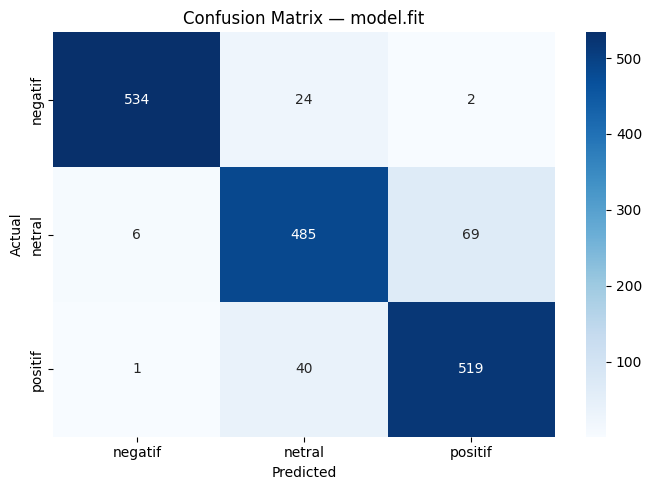

In [21]:
loss_fit, acc_fit = model.evaluate(X_val_vec, y_val, verbose=0)
print(f"model.fit — val_loss: {loss_fit:.4f} | val_accuracy: {acc_fit:.4f}")

y_pred_proba = model.predict(X_val_vec)
y_pred = np.argmax(y_pred_proba, axis=1)

label_names = ['negatif', 'netral', 'positif']
print()
print("=" * 55)
print("CLASSIFICATION REPORT (model.fit)")
print("=" * 55)
print(classification_report(y_val, y_pred, target_names=label_names))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — model.fit')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

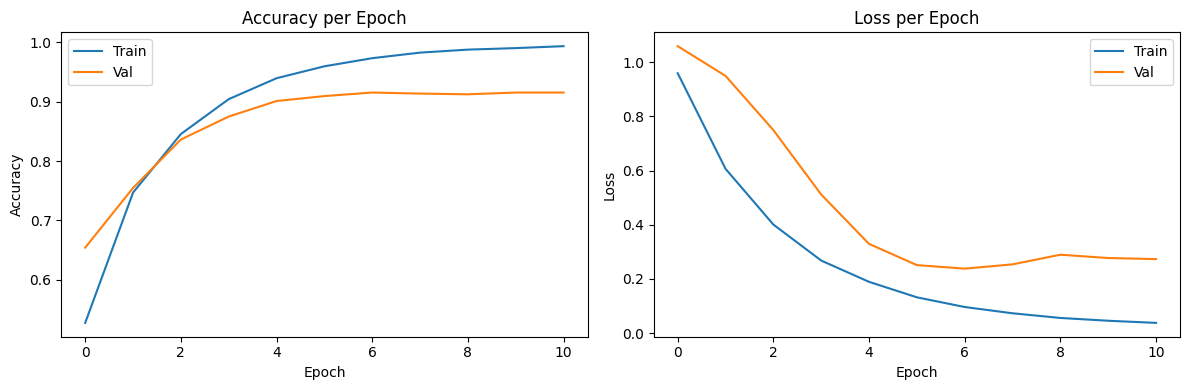

In [22]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 10. Custom Training Loop dengan tf.GradientTape

In [23]:
model_gt = build_model()

optimizer_gt   = tf.keras.optimizers.Adam(learning_rate=3e-4)
loss_fn_gt     = WeightedSparseCCE(class_weights)
train_acc_m    = tf.keras.metrics.SparseCategoricalAccuracy()
val_acc_m      = tf.keras.metrics.SparseCategoricalAccuracy()
train_loss_m   = tf.keras.metrics.Mean()

EPOCHS_GT    = 20
BATCH_GT     = 64
PATIENCE_GT  = 4

train_ds_gt = tf.data.Dataset.from_tensor_slices((X_train_vec, y_train)) \
    .shuffle(len(X_train)).batch(BATCH_GT).prefetch(tf.data.AUTOTUNE)
val_ds_gt = tf.data.Dataset.from_tensor_slices((X_val_vec, y_val)) \
    .batch(BATCH_GT).prefetch(tf.data.AUTOTUNE)

history_gt   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
patience_cnt = 0

print("Memulai custom training loop dengan tf.GradientTape...")
print("=" * 60)

for epoch in range(EPOCHS_GT):
    train_acc_m.reset_state()
    train_loss_m.reset_state()
    val_acc_m.reset_state()
    val_loss_list = []

    for x_batch, y_batch in train_ds_gt:
        with tf.GradientTape() as tape:
            y_hat = model_gt(x_batch, training=True)
            loss  = loss_fn_gt(y_batch, y_hat)
        grads = tape.gradient(loss, model_gt.trainable_variables)
        optimizer_gt.apply_gradients(zip(grads, model_gt.trainable_variables))
        train_acc_m.update_state(y_batch, y_hat)
        train_loss_m.update_state(loss)

    for x_batch, y_batch in val_ds_gt:
        y_hat_val = model_gt(x_batch, training=False)
        val_loss  = loss_fn_gt(y_batch, y_hat_val)
        val_acc_m.update_state(y_batch, y_hat_val)
        val_loss_list.append(val_loss.numpy())

    tr_acc  = train_acc_m.result().numpy()
    tr_loss = train_loss_m.result().numpy()
    vl_acc  = val_acc_m.result().numpy()
    vl_loss = np.mean(val_loss_list)

    history_gt['train_acc'].append(float(tr_acc))
    history_gt['train_loss'].append(float(tr_loss))
    history_gt['val_acc'].append(float(vl_acc))
    history_gt['val_loss'].append(float(vl_loss))

    gap    = tr_acc - vl_acc
    status = "OVERFIT" if gap > 0.10 else "OK"
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS_GT} | "
        f"loss: {tr_loss:.4f} acc: {tr_acc:.4f} | "
        f"val_loss: {vl_loss:.4f} val_acc: {vl_acc:.4f} | "
        f"gap: {gap:.4f} [{status}]"
    )

    if vl_acc > best_val_acc + 0.002:
        best_val_acc = vl_acc
        model_gt.save_weights('best_gt_weights.weights.h5')
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE_GT:
            print(f"Early stopping di epoch {epoch+1}")
            break

model_gt.load_weights('best_gt_weights.weights.h5')
print("=" * 60)
print(f"GradientTape selesai. Best val_acc: {best_val_acc:.4f}")

Memulai custom training loop dengan tf.GradientTape...
Epoch 01/20 | loss: 0.8838 acc: 0.5716 | val_loss: 1.0322 val_acc: 0.6506 | gap: -0.0790 [OK]
Epoch 02/20 | loss: 0.5328 acc: 0.7753 | val_loss: 0.9082 val_acc: 0.7893 | gap: -0.0140 [OK]
Epoch 03/20 | loss: 0.3461 acc: 0.8662 | val_loss: 0.7062 val_acc: 0.8530 | gap: 0.0132 [OK]
Epoch 04/20 | loss: 0.2392 acc: 0.9132 | val_loss: 0.4809 val_acc: 0.8792 | gap: 0.0341 [OK]
Epoch 05/20 | loss: 0.1699 acc: 0.9420 | val_loss: 0.3242 val_acc: 0.8917 | gap: 0.0503 [OK]
Epoch 06/20 | loss: 0.1174 acc: 0.9629 | val_loss: 0.2621 val_acc: 0.9042 | gap: 0.0588 [OK]
Epoch 07/20 | loss: 0.0963 acc: 0.9698 | val_loss: 0.2477 val_acc: 0.9149 | gap: 0.0549 [OK]
Epoch 08/20 | loss: 0.0582 acc: 0.9835 | val_loss: 0.2666 val_acc: 0.9143 | gap: 0.0692 [OK]
Epoch 09/20 | loss: 0.0482 acc: 0.9859 | val_loss: 0.2800 val_acc: 0.9125 | gap: 0.0734 [OK]
Epoch 10/20 | loss: 0.0395 acc: 0.9891 | val_loss: 0.2914 val_acc: 0.9125 | gap: 0.0766 [OK]
Epoch 11/20 |

## 11. Evaluasi GradientTape Model

GradientTape — val_loss: 0.2573 | val_accuracy: 0.9149
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

CLASSIFICATION REPORT (GradientTape)
              precision    recall  f1-score   support

     negatif       0.98      0.96      0.97       560
      netral       0.88      0.87      0.88       560
     positif       0.89      0.91      0.90       560

    accuracy                           0.91      1680
   macro avg       0.92      0.91      0.92      1680
weighted avg       0.92      0.91      0.92      1680



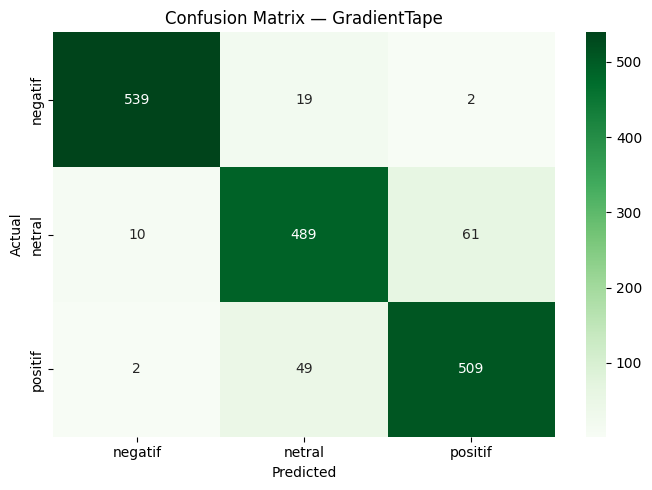

In [24]:
model_gt.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
loss_gt, acc_gt = model_gt.evaluate(X_val_vec, y_val, verbose=0)
print(f"GradientTape — val_loss: {loss_gt:.4f} | val_accuracy: {acc_gt:.4f}")

y_pred_gt = np.argmax(model_gt.predict(X_val_vec), axis=1)
print()
print("=" * 55)
print("CLASSIFICATION REPORT (GradientTape)")
print("=" * 55)
print(classification_report(y_val, y_pred_gt, target_names=label_names))

cm_gt = confusion_matrix(y_val, y_pred_gt)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_gt, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix — GradientTape')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 12. Perbandingan & Seleksi Model Terbaik

In [25]:
print("=" * 55)
print("PERBANDINGAN MODEL")
print("=" * 55)
print(f"model.fit      → val_accuracy: {acc_fit:.4f}")
print(f"GradientTape   → val_accuracy: {acc_gt:.4f}")
print()

if acc_gt > acc_fit:
    best_model = model_gt
    best_name  = 'GradientTape'
    best_acc   = acc_gt
else:
    best_model = model
    best_name  = 'model.fit'
    best_acc   = acc_fit

print(f"Model yang diekspor: {best_name} (val_acc: {best_acc:.4f})")
print()

if best_acc >= 0.85:
    print("Target akurasi >= 85% TERCAPAI")
else:
    print(f"Akurasi saat ini: {best_acc:.4f} — pertimbangkan fine-tune lebih lanjut")

PERBANDINGAN MODEL
model.fit      → val_accuracy: 0.9155
GradientTape   → val_accuracy: 0.9149

Model yang diekspor: model.fit (val_acc: 0.9155)

Target akurasi >= 85% TERCAPAI


## 13. Simpan Model (.keras + SavedModel)

In [26]:
best_model.save('final_model.keras')
print("Model disimpan: final_model.keras")

os.makedirs('saved_model/sentiment_model', exist_ok=True)
best_model.export('saved_model/sentiment_model')
print("SavedModel disimpan: saved_model/sentiment_model")

loaded_sm = tf.saved_model.load('saved_model/sentiment_model')
print("SavedModel berhasil di-load ulang")

shutil.make_archive('saved_model_folder', 'zip', 'saved_model')
print("saved_model_folder.zip siap")

Model disimpan: final_model.keras
Saved artifact at 'saved_model/sentiment_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50), dtype=tf.float32, name='input_text')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133441434590800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133441434593680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133441434591952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133441434594640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133441434595600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133441434595408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133441434594448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133441434595984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133441434595792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133441434596560: TensorSpec(shape=(), dtype=tf.res

## 14. TensorBoard Logs (termasuk GradientTape)

In [27]:
log_dir_gt = os.path.join('logs', 'gradient_tape')
os.makedirs(log_dir_gt, exist_ok=True)

writer_gt = tf.summary.create_file_writer(log_dir_gt)
with writer_gt.as_default():
    for step, (tr_acc, tr_loss, vl_acc, vl_loss) in enumerate(zip(
        history_gt['train_acc'], history_gt['train_loss'],
        history_gt['val_acc'], history_gt['val_loss']
    )):
        tf.summary.scalar('epoch_accuracy',     tr_acc,  step=step)
        tf.summary.scalar('epoch_val_accuracy', vl_acc,  step=step)
        tf.summary.scalar('epoch_loss',         tr_loss, step=step)
        tf.summary.scalar('epoch_val_loss',     vl_loss, step=step)
    writer_gt.flush()

print("TensorBoard logs GradientTape disimpan di:", log_dir_gt)

shutil.make_archive('tensorboard_logs', 'zip', 'logs')
print("tensorboard_logs.zip siap")

TensorBoard logs GradientTape disimpan di: logs/gradient_tape
tensorboard_logs.zip siap


## 15. Inference Code

In [28]:
_LABEL_MAP = {0: 'negatif', 1: 'netral', 2: 'positif'}

def predict_sentiment(text: str, model_to_use=None, threshold_conf: float = 0.45):
    if model_to_use is None:
        model_to_use = best_model

    clean = preprocess(text)
    if not clean.strip():
        return {'label': 'netral', 'confidence': 0.0, 'probabilities': {'negatif': 0.0, 'netral': 1.0, 'positif': 0.0}, 'clean_text': clean}

    vec = vectorizer([clean])
    proba = model_to_use(vec, training=False).numpy()[0]
    pred_idx = int(np.argmax(proba))
    confidence = float(proba[pred_idx])

    if confidence < threshold_conf:
        pred_idx = 1

    return {
        'label': _LABEL_MAP[pred_idx],
        'confidence': round(confidence, 4),
        'probabilities': {
            'negatif': round(float(proba[0]), 4),
            'netral':  round(float(proba[1]), 4),
            'positif': round(float(proba[2]), 4),
        },
        'clean_text': clean
    }

test_inputs = [
    "Untuk servernya full dan error jadi agak susah saat mengerjakan",
    "Sudah baik untuk tahun ini namun akan lebih baik jika dilaksanakan secara langsung",
    "Semoga lebih baik",
    "membosankan",
    "website ngelag parah banget gak bisa akses sama sekali",
    "Tolong perbaiki sistem PKKMB yang sangat kacau ini",
    "Sangat puas dengan pelaksanaan PKKMB tahun ini, panitia keren!",
    "Pkkmb online cukup baik tapi perlu ditingkatkan lagi",
    "Sistem error terus tidak bisa submit tugas sama sekali",
    "Keren banget acaranya mantap panitia sudah bekerja keras",
    "informasi kurang jelas dan terlambat disampaikan",
    "seru dan informatif terima kasih panitia PKKMB",
    "server lambat tidak bisa diakses kecewa banget",
    "ada kekurangan tapi lumayan oke lah",
    "sangat mengecewakan tidak ada persiapan sama sekali",
]

print("=" * 65)
print("INFERENCE TEST")
print("=" * 65)
for txt in test_inputs:
    result = predict_sentiment(txt)
    print(f"Input: {txt[:60]}")
    print(f"  Label: {result['label'].upper()} | Confidence: {result['confidence']:.4f}")
    print(f"  Proba: neg={result['probabilities']['negatif']:.3f} | neu={result['probabilities']['netral']:.3f} | pos={result['probabilities']['positif']:.3f}")
    print()

INFERENCE TEST
Input: Untuk servernya full dan error jadi agak susah saat mengerja
  Label: NEGATIF | Confidence: 0.9960
  Proba: neg=0.996 | neu=0.004 | pos=0.000

Input: Sudah baik untuk tahun ini namun akan lebih baik jika dilaks
  Label: POSITIF | Confidence: 0.9973
  Proba: neg=0.000 | neu=0.003 | pos=0.997

Input: Semoga lebih baik
  Label: POSITIF | Confidence: 0.9920
  Proba: neg=0.000 | neu=0.008 | pos=0.992

Input: membosankan
  Label: NETRAL | Confidence: 0.8367
  Proba: neg=0.146 | neu=0.837 | pos=0.017

Input: website ngelag parah banget gak bisa akses sama sekali
  Label: NEGATIF | Confidence: 0.9934
  Proba: neg=0.993 | neu=0.007 | pos=0.000

Input: Tolong perbaiki sistem PKKMB yang sangat kacau ini
  Label: POSITIF | Confidence: 0.9733
  Proba: neg=0.000 | neu=0.026 | pos=0.973

Input: Sangat puas dengan pelaksanaan PKKMB tahun ini, panitia kere
  Label: POSITIF | Confidence: 0.9905
  Proba: neg=0.000 | neu=0.009 | pos=0.991

Input: Pkkmb online cukup baik tapi perlu di

## 16. Export File untuk Download

In [29]:
!pip freeze > requirements.txt
print("requirements.txt disimpan")

try:
    from google.colab import files
    files.download('final_model.keras')
    files.download('saved_model_folder.zip')
    files.download('tensorboard_logs.zip')
    files.download('vectorizer_config.json')
    files.download('requirements.txt')
    print("Semua file siap didownload")
except ImportError:
    print("Bukan environment Colab — file ada di direktori kerja")
    print("File yang dihasilkan:")
    for f in ['final_model.keras', 'saved_model_folder.zip', 'tensorboard_logs.zip', 'vectorizer_config.json', 'requirements.txt']:
        exists = os.path.exists(f)
        print(f"  {'OK' if exists else 'MISSING'} — {f}")

requirements.txt disimpan


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Semua file siap didownload
